# De prototipo explosivo a vehículo orbital: análisis de la evolución de Starship

El 28 de septiembre de 2026, Starship alcanzó la órbita terrestre por primera vez. El hito llegó después de trece vuelos integrados marcados por explosiones, pérdidas de control, amerizajes, capturas del booster y avances que no siempre siguieron una trayectoria lineal.

En este proyecto analizo los 14 vuelos integrados de Starship y Super Heavy para responder una pregunta: **¿qué muestran los datos sobre la evolución real del programa?**

En lugar de clasificar cada misión únicamente como éxito o fracaso, estudiaré las capacidades que consiguió demostrar: separación de etapas, llegada al espacio, reentrada, retorno controlado, despliegue de carga, reencendido de motores e inserción orbital.

## Preparación del análisis

Importo las librerías que utilizaré para cargar, transformar y visualizar los datos.

In [1]:
# importo las librerías necesarias
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# configuro el estilo general de las visualizaciones
sns.set_theme(
    style="whitegrid",
    palette="deep"
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## Carga del dataset

Trabajo con un dataset construido a partir de los resúmenes de misión de SpaceX y contrastado con fuentes independientes. Cada fila representa uno de los 14 vuelos integrados realizados entre abril de 2023 y septiembre de 2026.

In [2]:
# defino la ruta del dataset
ruta_datos = Path("starship_flights_1_14.csv")

# cargo los datos y convierto la fecha de lanzamiento
df = pd.read_csv(
    ruta_datos,
    parse_dates=["launch_date"]
)

# compruebo el tamaño del dataset
print(f"el dataset contiene {df.shape[0]} vuelos y {df.shape[1]} variables")

# reviso las primeras observaciones
display(df.head())

el dataset contiene 14 vuelos y 22 variables


,flight_number,launch_date,vehicle_generation,liftoff_successful,stage_separation_successful,ship_reached_space,ship_full_ascent_burn,booster_controlled_return,booster_caught,ship_reentry_started,ship_controlled_splashdown,payload_deployed,payload_count,payload_type,in_space_raptor_relight,orbit_achieved,booster_outcome,ship_outcome,main_milestone,main_anomaly,primary_source,secondary_source
0,1,2023-04-20,V1,1,0,0,0,0,0,0,0,0,0,none,0,0,lost with the integrated vehicle after loss of control,lost after the flight termination system was activated,first liftoff of the fully integrated Starship and Super Heavy system,propellant leaks and fires caused loss of communications and control; the vehicle began tumbling,https://www.spacex.com/updates/#upgrades-ahead-of-starships-second-flight-test,https://en.wikipedia.org/wiki/Starship_flight_test_1
1,2,2023-11-18,V1,1,1,1,0,0,0,0,0,0,0,none,0,0,lost after stage separation during the boostback sequence,lost before completing the ascent burn at about 150 km altitude,first successful hot-stage separation and first Starship to reach space,an oxygen venting operation led to a leak and combustion event in the ship; the flight termination system activated,https://www.spacex.com/updates/#building-on-the-success-of-starships-second-flight-test,https://en.wikipedia.org/wiki/Starship_flight_test_2
2,3,2024-03-14,V1,1,1,1,1,0,0,1,0,0,0,none,0,0,lost during the attempted landing burn,lost during an off-nominal atmospheric reentry,first full-duration ship ascent; payload-door test and internal propellant-transfer demonstration,the booster landing burn did not complete; clogged roll-control valves caused loss of ship attitude control,https://www.spacex.com/updates/#starships-third-flight-test,https://newatlas.com/space/starship-the-worlds-largest-most-powerful-rocket-reaches-orbit/
3,4,2024-06-06,V1,1,1,1,1,1,0,1,1,0,0,none,0,0,controlled soft splashdown in the Gulf of Mexico,controlled soft splashdown in the Indian Ocean,first controlled return and soft splashdown of both stages,one booster engine shut down after liftoff and the ship suffered visible heat-shield and flap damage during reentry,https://www.spacex.com/launches/mission/?missionId=starship-flight-4,https://apnews.com/article/81c9279f30ca98be1c01b84ceb895e90
4,5,2024-10-13,V1,1,1,1,1,1,1,1,1,0,0,none,0,0,caught by the launch tower arms at Starbase,controlled soft splashdown in the Indian Ocean,first catch of a Super Heavy booster on the first attempt,the ship sustained heat-shield and flap damage but completed its planned return,https://www.youtube.com/watch?v=hI9HQfCAw64,https://apnews.com/article/7af865e987bb4a2aad38759e06013626


### Primera inspección de los datos

El dataset contiene pocos registros, pero combina variables numéricas, categóricas, binarias y textuales. Para obtener una primera lectura más clara, selecciono las columnas que resumen la evolución de cada vuelo.

In [3]:
# selecciono las variables más útiles para la primera inspección
columnas_resumen = [
    "flight_number",
    "launch_date",
    "vehicle_generation",
    "stage_separation_successful",
    "ship_full_ascent_burn",
    "booster_controlled_return",
    "booster_caught",
    "ship_controlled_splashdown",
    "payload_deployed",
    "in_space_raptor_relight",
    "orbit_achieved"
]

# muestro una versión más manejable del dataset
display(
    df[columnas_resumen]
    .set_index("flight_number")
)

,launch_date,vehicle_generation,stage_separation_successful,ship_full_ascent_burn,booster_controlled_return,booster_caught,ship_controlled_splashdown,payload_deployed,in_space_raptor_relight,orbit_achieved
flight_number,,,,,,,,,,
1,2023-04-20,V1,0,0,0,0,0,0,0,0
2,2023-11-18,V1,1,0,0,0,0,0,0,0
3,2024-03-14,V1,1,1,0,0,0,0,0,0
4,2024-06-06,V1,1,1,1,0,1,0,0,0
5,2024-10-13,V1,1,1,1,1,1,0,0,0
6,2024-11-19,V1,1,1,1,0,1,0,1,0
7,2025-01-16,V2,1,0,1,1,0,0,0,0
8,2025-03-06,V2,1,0,1,1,0,0,0,0
9,2025-05-27,V2,1,1,0,0,0,0,0,0


In [4]:
# compruebo los duplicados y los valores ausentes
print("filas duplicadas:", df.duplicated().sum())
print("valores ausentes:", df.isna().sum().sum())

# reviso si alguna columna contiene valores ausentes
columnas_con_nulos = (
    df.isna()
    .sum()
    .loc[lambda serie: serie > 0]
)

display(columnas_con_nulos)

filas duplicadas: 0
valores ausentes: 0


Series([], dtype: int64)

### Una evolución con avances y retrocesos

La primera inspección muestra que Starship no avanzó de forma lineal. La separación de etapas se consiguió en el segundo vuelo y la nave completó su ascenso por primera vez en el tercero. El cuarto vuelo añadió el retorno controlado de ambas etapas y el quinto logró capturar el booster.

Sin embargo, los vuelos 7 y 8 no completaron el ascenso de la nave, aunque el booster sí regresó a la torre. La estabilidad reapareció a partir del vuelo 10, cuando también comenzó el despliegue de cargas. La inserción orbital no llegó hasta el vuelo 14.

In [5]:
# identifico las columnas que representan capacidades binarias
columnas_binarias = [
    "liftoff_successful",
    "stage_separation_successful",
    "ship_reached_space",
    "ship_full_ascent_burn",
    "booster_controlled_return",
    "booster_caught",
    "ship_reentry_started",
    "ship_controlled_splashdown",
    "payload_deployed",
    "in_space_raptor_relight",
    "orbit_achieved"
]

# compruebo que todas las capacidades estén codificadas con ceros y unos
valores_invalidos = {
    columna: sorted(
        set(df[columna].dropna()) - {0, 1}
    )
    for columna in columnas_binarias
}

# conservo únicamente las columnas que contienen algún valor incorrecto
valores_invalidos = {
    columna: valores
    for columna, valores in valores_invalidos.items()
    if valores
}

print("valores binarios incorrectos:", valores_invalidos)

valores binarios incorrectos: {}


## Medir la evolución del programa

Para resumir la evolución, construiré dos indicadores:

- **Hitos observados en cada vuelo:** número de capacidades demostradas durante una misión concreta.
- **Hitos acumulados por el programa:** número de capacidades que Starship ya había demostrado al menos una vez hasta ese vuelo.

Todos los hitos reciben el mismo peso. Por tanto, estos indicadores no representan una tasa oficial de éxito ni miden la dificultad técnica de cada objetivo. Solo permiten visualizar cómo se acumularon las capacidades del programa y dónde se produjeron retrocesos.

In [6]:
# excluyo el despegue porque se completó en los 14 vuelos
columnas_hitos = [
    columna
    for columna in columnas_binarias
    if columna != "liftoff_successful"
]

# cuento los hitos observados durante cada vuelo
df["hitos_vuelo"] = df[columnas_hitos].sum(axis=1)

# calculo qué capacidades ya se habían demostrado hasta cada misión
hitos_demostrados = df[columnas_hitos].cummax()

# cuento los hitos acumulados por el programa
df["hitos_acumulados"] = hitos_demostrados.sum(axis=1)

# reviso la evolución de ambos indicadores
display(
    df[
        [
            "flight_number",
            "vehicle_generation",
            "hitos_vuelo",
            "hitos_acumulados"
        ]
    ].set_index("flight_number")
)

,vehicle_generation,hitos_vuelo,hitos_acumulados
flight_number,,,
1,V1,0,0
2,V1,2,2
3,V1,4,4
4,V1,6,6
5,V1,7,7
6,V1,7,8
7,V2,4,8
8,V2,4,8
9,V2,4,8


### El conocimiento se acumula aunque cada vuelo pueda retroceder

La primera generación amplió rápidamente la frontera técnica del programa: pasó de no completar ningún hito posterior al despegue en el vuelo 1 a acumular ocho capacidades diferentes en el vuelo 6.

La llegada de Starship V2 produjo un retroceso visible. Los vuelos 7, 8 y 9 solo completaron cuatro hitos cada uno y no añadieron capacidades nuevas. Los vuelos 10 y 11 recuperaron el nivel anterior e incorporaron el despliegue de carga.

Los primeros vuelos de V3 tampoco aumentaron inmediatamente el número de capacidades acumuladas. El salto final llegó en el vuelo 14, cuando Starship consiguió la inserción orbital.

Este indicador simplifica la historia: no distingue entre simuladores y satélites operativos ni refleja mejoras dentro de una capacidad ya demostrada. Su utilidad está en mostrar que el aprendizaje del programa se acumuló de forma escalonada, mientras el rendimiento de cada vuelo sufrió avances y retrocesos.

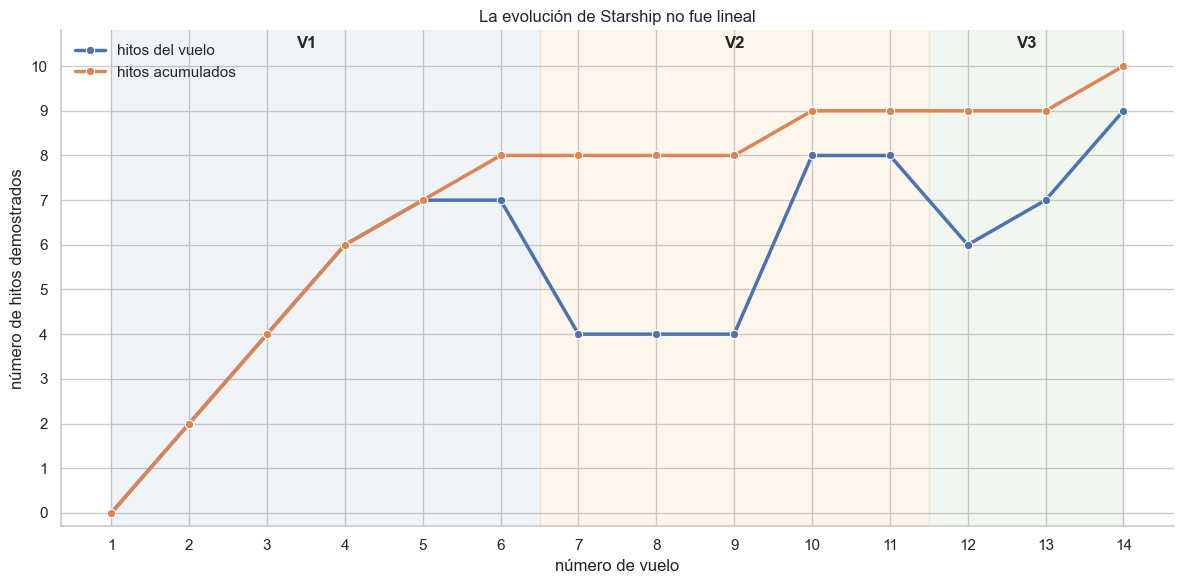

In [8]:
# creo una figura para comparar el rendimiento de cada vuelo con el aprendizaje acumulado
fig, ax = plt.subplots(figsize=(12, 6))

# represento los hitos observados en cada misión
sns.lineplot(
    data=df,
    x="flight_number",
    y="hitos_vuelo",
    marker="o",
    linewidth=2.5,
    label="hitos del vuelo",
    ax=ax
)

# represento la frontera acumulada del programa
sns.lineplot(
    data=df,
    x="flight_number",
    y="hitos_acumulados",
    marker="o",
    linewidth=2.5,
    label="hitos acumulados",
    ax=ax
)

# marco las tres generaciones del vehículo
ax.axvspan(1, 6.5, color="#4c78a8", alpha=0.08)
ax.axvspan(6.5, 11.5, color="#f58518", alpha=0.08)
ax.axvspan(11.5, 14, color="#54a24b", alpha=0.08)

# identifico cada generación dentro del gráfico
ax.text(3.5, 10.4, "V1", ha="center", weight="bold")
ax.text(9, 10.4, "V2", ha="center", weight="bold")
ax.text(12.75, 10.4, "V3", ha="center", weight="bold")

# ajusto los títulos y los ejes
ax.set(
    title="La evolución de Starship no fue lineal",
    xlabel="número de vuelo",
    ylabel="número de hitos demostrados",
    xticks=range(1, 15),
    yticks=range(0, 11),
    ylim=(-0.3, 10.8)
)

ax.legend(frameon=False)
sns.despine()

plt.tight_layout()
plt.show()

### El progreso técnico sobrevivió a los vuelos fallidos

Durante los seis vuelos de V1, la frontera técnica del programa creció de manera casi continua. Al terminar esta generación, Starship ya había demostrado ocho de los diez hitos analizados.

V2 comenzó con tres misiones que no ampliaron esa frontera. Los vuelos 7, 8 y 9 completaron únicamente cuatro hitos cada uno, aunque sus problemas no borraron las capacidades demostradas anteriormente. La recuperación llegó en los vuelos 10 y 11, que igualaron el mejor rendimiento acumulado e incorporaron el despliegue de carga.

V3 necesitó tres vuelos para superar esa frontera. El vuelo 14 reunió nueve hitos en una misma misión y añadió el décimo que faltaba: la inserción orbital.

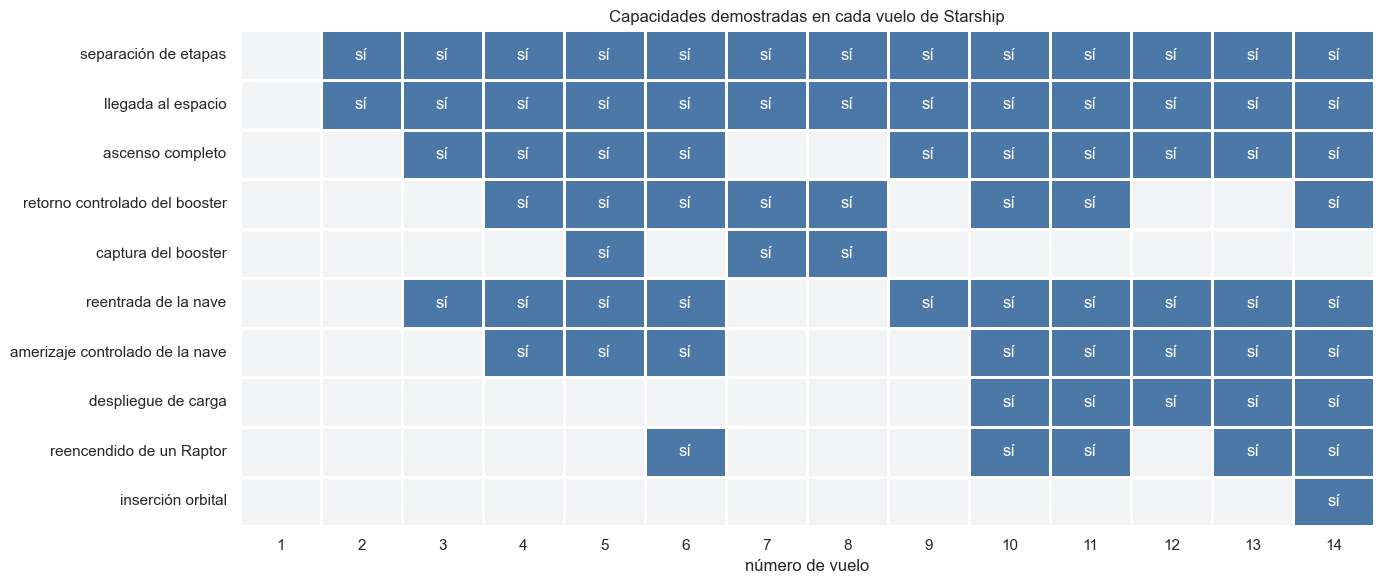

In [10]:
# traduzco los nombres técnicos para facilitar la lectura
nombres_hitos = {
    "stage_separation_successful": "separación de etapas",
    "ship_reached_space": "llegada al espacio",
    "ship_full_ascent_burn": "ascenso completo",
    "booster_controlled_return": "retorno controlado del booster",
    "booster_caught": "captura del booster",
    "ship_reentry_started": "reentrada de la nave",
    "ship_controlled_splashdown": "amerizaje controlado de la nave",
    "payload_deployed": "despliegue de carga",
    "in_space_raptor_relight": "reencendido de un Raptor",
    "orbit_achieved": "inserción orbital"
}

# construyo una matriz con los vuelos en columnas y los hitos en filas
mapa_hitos = (
    df
    .set_index("flight_number")[columnas_hitos]
    .rename(columns=nombres_hitos)
    .T
)

# sustituyo los unos por marcas visuales y oculto los ceros
anotaciones = mapa_hitos.replace({
    0: "",
    1: "sí"
})

# represento la secuencia de capacidades demostradas
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    mapa_hitos,
    annot=anotaciones,
    fmt="",
    cmap=["#f1f3f5", "#4c78a8"],
    cbar=False,
    linewidths=0.8,
    linecolor="white",
    ax=ax
)

# ajusto los títulos y las etiquetas
ax.set(
    title="Capacidades demostradas en cada vuelo de Starship",
    xlabel="número de vuelo",
    ylabel=""
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.tick_params(
    axis="y",
    rotation=0
)

plt.tight_layout()
plt.show()

### La nave y el booster no evolucionaron al mismo ritmo

Las capacidades básicas de vuelo aparecieron pronto. Starship consiguió separar sus etapas y alcanzar el espacio en el vuelo 2, mientras que el ascenso completo llegó en el vuelo 3.

Los vuelos 4, 5 y 6 consolidaron el retorno de ambas etapas. Sin embargo, el estreno de V2 rompió temporalmente esa progresión: los vuelos 7 y 8 capturaron el booster, pero perdieron la nave durante el ascenso. El vuelo 9 completó el ascenso, aunque no consiguió recuperar ninguna de las dos etapas de forma controlada.

El despliegue de carga comenzó en el vuelo 10 y se repitió en todas las misiones posteriores. La inserción orbital fue la última capacidad de la matriz en aparecer, durante el vuelo 14.

La visualización también muestra que alcanzar la órbita no exigió capturar el booster en esa misma misión. La captura y la capacidad orbital son avances diferentes dentro del objetivo más amplio de construir un sistema completamente reutilizable.

In [11]:
# localizo el primer vuelo en el que se demostró cada capacidad
primeros_hitos = []

for columna in columnas_hitos:
    indice = df[columna].eq(1).idxmax()
    vuelo = df.loc[indice]

    primeros_hitos.append({
        "capacidad": nombres_hitos[columna],
        "primer_vuelo": vuelo["flight_number"],
        "fecha": vuelo["launch_date"],
        "generacion": vuelo["vehicle_generation"]
    })

# convierto los resultados en una tabla ordenada
primeros_hitos = (
    pd.DataFrame(primeros_hitos)
    .sort_values(["primer_vuelo", "capacidad"])
    .reset_index(drop=True)
)

display(primeros_hitos)

,capacidad,primer_vuelo,fecha,generacion
0,llegada al espacio,2,2023-11-18,V1
1,separación de etapas,2,2023-11-18,V1
2,ascenso completo,3,2024-03-14,V1
3,reentrada de la nave,3,2024-03-14,V1
4,amerizaje controlado de la nave,4,2024-06-06,V1
5,retorno controlado del booster,4,2024-06-06,V1
6,captura del booster,5,2024-10-13,V1
7,reencendido de un Raptor,6,2024-11-19,V1
8,despliegue de carga,10,2025-08-26,V2
9,inserción orbital,14,2026-09-28,V3


## El tiempo entre vuelos

SpaceX presenta el ensayo frecuente como una parte central de su método de desarrollo. Para comprobar cómo evolucionó ese ritmo, calculo los días transcurridos entre cada lanzamiento.

También identifico cuántos hitos nuevos añadió cada misión. Esta comparación permitirá observar si volar de nuevo rápidamente estuvo acompañado siempre por una ampliación de las capacidades demostradas.

In [12]:
# calculo los días transcurridos desde el vuelo anterior
df["dias_desde_anterior"] = (
    df["launch_date"]
    .diff()
    .dt.days
)

# calculo cuántos hitos nuevos añadió cada misión
df["hitos_nuevos"] = (
    df["hitos_acumulados"]
    .diff()
    .fillna(df["hitos_acumulados"])
    .astype(int)
)

# preparo una tabla para revisar el ritmo de desarrollo
ritmo_vuelos = df[
    [
        "flight_number",
        "launch_date",
        "vehicle_generation",
        "dias_desde_anterior",
        "hitos_nuevos"
    ]
].copy()

display(
    ritmo_vuelos.set_index("flight_number")
)

,launch_date,vehicle_generation,dias_desde_anterior,hitos_nuevos
flight_number,,,,
1,2023-04-20,V1,NaN,0
2,2023-11-18,V1,212.0,2
3,2024-03-14,V1,117.0,2
4,2024-06-06,V1,84.0,2
5,2024-10-13,V1,129.0,1
6,2024-11-19,V1,37.0,1
7,2025-01-16,V2,58.0,0
8,2025-03-06,V2,49.0,0
9,2025-05-27,V2,82.0,0


### Volar antes no siempre significó avanzar más

Los intervalos entre lanzamientos se redujeron después de los primeros vuelos, pero los nuevos hitos no aparecieron a un ritmo constante. Para comparar ambas variables, represento el tiempo transcurrido entre misiones e identifico los vuelos que ampliaron la frontera técnica del programa.

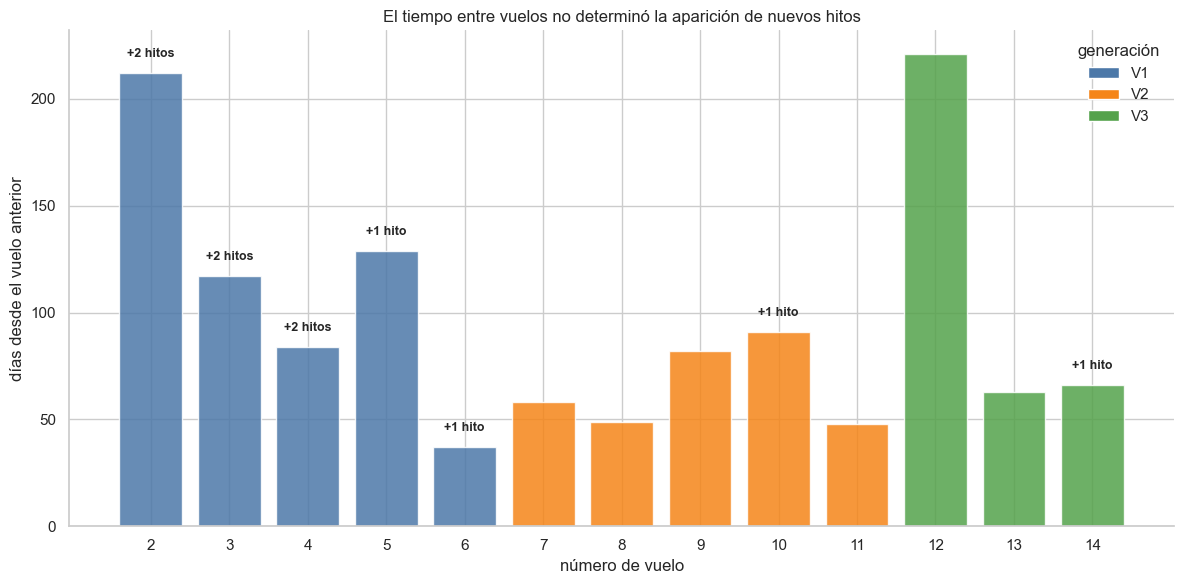

In [13]:
# importo una herramienta para construir la leyenda
from matplotlib.patches import Patch

# elimino el primer vuelo porque no tiene una misión anterior
datos_ritmo = df.dropna(
    subset=["dias_desde_anterior"]
).copy()

# asigno un color a cada generación
colores_generacion = {
    "V1": "#4c78a8",
    "V2": "#f58518",
    "V3": "#54a24b"
}

# represento los días transcurridos entre vuelos
fig, ax = plt.subplots(figsize=(12, 6))

barras = ax.bar(
    datos_ritmo["flight_number"],
    datos_ritmo["dias_desde_anterior"],
    color=datos_ritmo["vehicle_generation"].map(colores_generacion),
    alpha=0.85
)

# señalo las misiones que añadieron capacidades nuevas
for barra, hitos in zip(
    barras,
    datos_ritmo["hitos_nuevos"]
):
    if hitos > 0:
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() + 6,
            f"+{hitos} hito" if hitos == 1 else f"+{hitos} hitos",
            ha="center",
            va="bottom",
            fontsize=9,
            weight="bold"
        )

# construyo una leyenda para las generaciones
leyenda_generaciones = [
    Patch(
        facecolor=color,
        label=generacion
    )
    for generacion, color in colores_generacion.items()
]

# ajusto los títulos y los ejes
ax.set(
    title="El tiempo entre vuelos no determinó la aparición de nuevos hitos",
    xlabel="número de vuelo",
    ylabel="días desde el vuelo anterior",
    xticks=range(2, 15)
)

ax.legend(
    handles=leyenda_generaciones,
    title="generación",
    frameon=False
)

sns.despine()
plt.tight_layout()
plt.show()

### La fase más rápida también acumuló varios intentos sin hitos nuevos

Durante V1, cinco vuelos consecutivos ampliaron la frontera de capacidades analizadas. El intervalo se redujo hasta alcanzar solo 37 días entre los vuelos 5 y 6.

V2 mantuvo una cadencia más rápida, pero sus tres primeras misiones no incorporaron ningún hito nuevo a la matriz. El vuelo 10 rompió esa secuencia con el primer despliegue de carga.

El estreno de V3 llegó después de la pausa más larga de toda la serie: 221 días. Sus dos primeros vuelos consolidaron y modificaron capacidades existentes, mientras que el vuelo 14 añadió la inserción orbital.

La ausencia de un hito nuevo no significa que una misión careciera de valor. El indicador no recoge cambios de arquitectura, ensayos sobre componentes ni mejoras dentro de una capacidad que ya había sido demostrada.

In [14]:
# resumo el ritmo y los hitos de cada generación
resumen_generaciones = (
    df
    .groupby("vehicle_generation", sort=False)
    .agg(
        vuelos=("flight_number", "count"),
        intervalo_mediano_dias=("dias_desde_anterior", "median"),
        mediana_hitos_por_vuelo=("hitos_vuelo", "median"),
        hitos_nuevos=("hitos_nuevos", "sum"),
        vuelos_con_hitos_nuevos=(
            "hitos_nuevos",
            lambda serie: int((serie > 0).sum())
        )
    )
    .round(1)
)

# traduzco los nombres para presentar la tabla
resumen_generaciones.columns = [
    "vuelos",
    "intervalo mediano en días",
    "mediana de hitos por vuelo",
    "hitos nuevos",
    "vuelos con hitos nuevos"
]

display(resumen_generaciones)

,vuelos,intervalo mediano en días,mediana de hitos por vuelo,hitos nuevos,vuelos con hitos nuevos
vehicle_generation,,,,,
V1,6,117.0,5.0,8,5
V2,5,58.0,4.0,1,1
V3,3,66.0,7.0,1,1


## De los simuladores a una carga orbital

El despliegue de carga apareció en el vuelo 10, pero no todos los elementos liberados tuvieron la misma función. Las primeras pruebas utilizaron simuladores y satélites experimentales que siguieron trayectorias suborbitales.

Para observar la transición hacia una misión operativa, comparo el número y el tipo de elementos desplegados, junto con la capacidad de alcanzar la órbita.

In [15]:
# selecciono únicamente los vuelos que desplegaron alguna carga
vuelos_con_carga = df.loc[
    df["payload_deployed"].eq(1),
    [
        "flight_number",
        "launch_date",
        "vehicle_generation",
        "payload_count",
        "payload_type",
        "in_space_raptor_relight",
        "orbit_achieved"
    ]
].copy()

# traduzco las columnas para presentar una tabla más clara
vuelos_con_carga.columns = [
    "vuelo",
    "fecha",
    "generación",
    "elementos desplegados",
    "tipo de carga",
    "reencendido espacial",
    "inserción orbital"
]

display(
    vuelos_con_carga.set_index("vuelo")
)

,fecha,generación,elementos desplegados,tipo de carga,reencendido espacial,inserción orbital
vuelo,,,,,,
10,2025-08-26,V2,8,Starlink mass simulators,1,0
11,2025-10-13,V2,8,Starlink mass simulators,1,0
12,2026-05-22,V3,22,20 Starlink simulators and 2 modified Starlink imaging satellites,0,0
13,2026-07-24,V3,20,Starlink V3 satellites on a suborbital trajectory,1,0
14,2026-09-28,V3,26,operational Starlink V3 satellites deployed to low Earth orbit,1,1


### Cinco despliegues antes de entrar en servicio orbital

Los vuelos 10 y 11 probaron el mecanismo con ocho simuladores de masa. V3 amplió el ensayo en el vuelo 12 mediante 20 simuladores y dos satélites modificados que fotografiaron la nave.

El vuelo 13 desplegó por primera vez satélites Starlink V3, aunque estos siguieron la misma trayectoria suborbital de Starship y reentraron poco después. El vuelo 14 completó la transición al colocar 26 satélites operativos en órbita terrestre baja.

El número de elementos no representa su masa ni permite comparar directamente la capacidad de carga de las misiones. Su utilidad es mostrar cómo el despliegue evolucionó desde una simulación hasta una operación orbital.

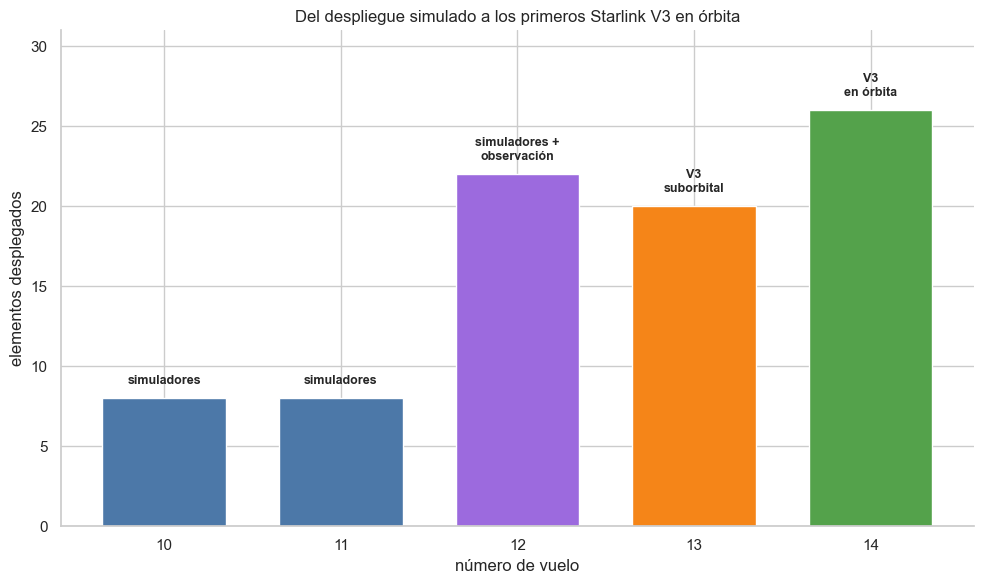

In [16]:
# defino una descripción breve para cada tipo de despliegue
etiquetas_carga = {
    10: "simuladores",
    11: "simuladores",
    12: "simuladores +\nobservación",
    13: "V3\nsuborbital",
    14: "V3\nen órbita"
}

# asigno colores según la función de cada carga
colores_carga = {
    10: "#4c78a8",
    11: "#4c78a8",
    12: "#9c6ade",
    13: "#f58518",
    14: "#54a24b"
}

# represento el número de elementos desplegados
fig, ax = plt.subplots(figsize=(10, 6))

barras = ax.bar(
    vuelos_con_carga["vuelo"],
    vuelos_con_carga["elementos desplegados"],
    color=[
        colores_carga[vuelo]
        for vuelo in vuelos_con_carga["vuelo"]
    ],
    width=0.7
)

# identifico la naturaleza de cada despliegue
for barra, vuelo in zip(
    barras,
    vuelos_con_carga["vuelo"]
):
    ax.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height() + 0.7,
        etiquetas_carga[vuelo],
        ha="center",
        va="bottom",
        fontsize=9,
        weight="bold"
    )

# ajusto los títulos y los ejes
ax.set(
    title="Del despliegue simulado a los primeros Starlink V3 en órbita",
    xlabel="número de vuelo",
    ylabel="elementos desplegados",
    xticks=vuelos_con_carga["vuelo"],
    ylim=(0, 31)
)

sns.despine()
plt.tight_layout()
plt.show()

## Balance de la campaña de vuelos

Antes de formular las conclusiones, resumo las dimensiones principales del proceso: duración, cadencia, capacidades nuevas y vuelos necesarios para alcanzar los hitos operativos.

In [17]:
# calculo la duración total de la campaña analizada
duracion_campana = (
    df["launch_date"].max()
    - df["launch_date"].min()
).days

# recupero los primeros vuelos con despliegue de carga y órbita
primer_vuelo_carga = int(
    df.loc[
        df["payload_deployed"].eq(1),
        "flight_number"
    ].min()
)

primer_vuelo_orbital = int(
    df.loc[
        df["orbit_achieved"].eq(1),
        "flight_number"
    ].min()
)

# reúno los principales resultados del análisis
metricas_clave = pd.DataFrame({
    "métrica": [
        "duración de la campaña analizada",
        "vuelos integrados",
        "hitos técnicos analizados",
        "vuelos que añadieron hitos nuevos",
        "intervalo mediano entre vuelos",
        "mayor intervalo entre vuelos",
        "primer vuelo con despliegue de carga",
        "primer vuelo orbital"
    ],
    "valor": [
        f"{duracion_campana} días",
        len(df),
        len(columnas_hitos),
        int(df["hitos_nuevos"].gt(0).sum()),
        f"{df['dias_desde_anterior'].median():.0f} días",
        f"{df['dias_desde_anterior'].max():.0f} días",
        primer_vuelo_carga,
        primer_vuelo_orbital
    ]
})

display(
    metricas_clave.set_index("métrica")
)

,valor
métrica,
duración de la campaña analizada,1257 días
vuelos integrados,14
hitos técnicos analizados,10
vuelos que añadieron hitos nuevos,7
intervalo mediano entre vuelos,82 días
mayor intervalo entre vuelos,221 días
primer vuelo con despliegue de carga,10
primer vuelo orbital,14


## Conclusiones

Starship necesitó 14 vuelos integrados y 1.257 días para pasar de un primer lanzamiento que terminó con la destrucción del vehículo a una misión capaz de alcanzar la órbita y desplegar 26 satélites operativos.

Los datos muestran que ese avance no fue lineal:

1. **La mayor expansión inicial ocurrió con V1.** Al finalizar sus seis vuelos, el programa ya había demostrado ocho de las diez capacidades analizadas.

2. **V2 combinó avances del booster con retrocesos de la nave.** Los vuelos 7 y 8 capturaron la primera etapa, pero no completaron el ascenso de Starship. El vuelo 9 recuperó esa capacidad, aunque perdió el retorno controlado de ambas etapas.

3. **Una mayor frecuencia de lanzamientos no garantizó hitos nuevos.** El intervalo mediano de la campaña fue de 82 días, pero solo siete de las catorce misiones ampliaron la frontera de capacidades estudiadas.

4. **El despliegue de carga necesitó una progresión propia.** Starship pasó de liberar simuladores en el vuelo 10 a desplegar satélites V3 en trayectoria suborbital durante el vuelo 13. La primera carga operativa en órbita llegó en el vuelo 14.

La primera inserción orbital no fue un salto aislado, sino el resultado de capacidades desarrolladas y combinadas durante más de tres años. Las explosiones y pérdidas de vehículos formaron parte de esa trayectoria, pero reducir cada misión a éxito o fracaso ocultaría buena parte del aprendizaje técnico acumulado.

## Limitaciones

Este análisis describe la evolución observable del programa, pero presenta varias limitaciones:

- El dataset contiene únicamente 14 vuelos, una muestra insuficiente para entrenar y validar responsablemente un modelo de machine learning o deep learning.
- Los objetivos cambiaron entre misiones. Una capacidad no demostrada en un vuelo podía no formar parte de sus objetivos.
- Los hitos reciben el mismo peso, aunque su dificultad y relevancia técnica no sean equivalentes.
- Las variables binarias no reflejan mejoras parciales, cambios de arquitectura, masa transportada ni la calidad de la ejecución.
- El análisis utiliza información pública. No incluye telemetría detallada ni datos internos de SpaceX.
- SpaceX es la principal fuente sobre sus propias misiones, por lo que los resultados se contrastaron con fuentes periodísticas independientes.

Por estas razones, el notebook debe interpretarse como un análisis exploratorio de la acumulación de capacidades, no como una medición oficial de fiabilidad ni como una predicción del resultado de futuros vuelos.